# MATPMD4
## Assignment 1 (Stochastic Processes)
### Student ID: 3019061
### Lecturer: Anthony O’Hare (4B113)

1) Yes I have read and understood the instructions on the cover page

# Q2 Markov chain / stochastic matrix solution

We are given the transition matrix

$$
P =
\begin{pmatrix}
0.21 & 0.07 & 0.15 & 0.11 & 0.46 \\
0.00 & 1.00 & 0.00 & 0.00 & 0.00 \\
0.16 & 0.16 & 0.22 & x    & 0.26 \\
0.00 & 0.00 & 0.00 & 1.00 & 0.00 \\
0.21 & 0.27 & 0.18 & 0.24 & 0.10
\end{pmatrix}
$$

with states $A,B,C,D,E$.

In [174]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

## Q2 (a) Find $x$

Because $P$ is a stochastic matrix, each row must sum to 1.

This must hold because each row represents the probabilities of moving from one state to all possible next states. Since the process must go somewhere after one step, the total probability in each row must be exactly 1.

Using the third row:

$$
0.16 + 0.16 + 0.22 + x + 0.26 = 1
$$

$$
0.80 + x = 1
$$

$$
x = 0.20
$$

So the missing value is

$$
{x = 0.20}
$$

n.b. Had to round x to prevent the sum being outputted as 0.19999996

In [175]:
x = 1 - (0.16 + 0.16 + 0.22 + 0.26)
print("x =", x.__round__(2))

P = np.array([
    [0.21, 0.07, 0.15, 0.11, 0.46],
    [0.00, 1.00, 0.00, 0.00, 0.00],
    [0.16, 0.16, 0.22, x,    0.26],
    [0.00, 0.00, 0.00, 1.00, 0.00],
    [0.21, 0.27, 0.18, 0.24, 0.10]
])

print("Transition matrix P:")
print(P)

x = 0.2
Transition matrix P:
[[0.21 0.07 0.15 0.11 0.46]
 [0.   1.   0.   0.   0.  ]
 [0.16 0.16 0.22 0.2  0.26]
 [0.   0.   0.   1.   0.  ]
 [0.21 0.27 0.18 0.24 0.1 ]]


The row sums are all equal to 1, confirming that $P$ is a valid stochastic matrix.

## Q2 (b) Distribution after 1, 2, and 3 generations

The initial distribution is

$$
\pi_0 = (0.13,\;0.24,\;0.32,\;0.28,\;0.03).
$$

Since this is a row vector, the update rule is

$$
\pi_{n+1} = \pi_n P.
$$

In [176]:
# Initial distribution
pi0 = np.array([0.13, 0.24, 0.32, 0.28, 0.03])

# Compute distributions after 1, 2, and 3 generations
pi1 = pi0 @ P
pi2 = pi1 @ P
pi3 = pi2 @ P

print("pi0 =", pi0)
print("pi1 =", pi1)
print("pi2 =", pi2)
print("pi3 =", pi3)

pi0 = [0.13 0.24 0.32 0.28 0.03]
pi1 = [0.0848 0.3084 0.0953 0.3655 0.146 ]
pi2 = [0.063716 0.369004 0.059966 0.428928 0.078386]
pi3 = [0.03943598 0.4042229  0.0368594  0.4667426  0.05273912]



The initial distribution is

$$
\pi_0 = (0.13,\;0.24,\;0.32,\;0.28,\;0.03)
$$

Since this is a row vector, the update rule is

$$
\pi_{n+1} = \pi_n P
$$

So we calculate:

- $\pi_1 = \pi_0 P$
- $\pi_2 = \pi_1 P$
- $\pi_3 = \pi_2 P$

### After 1 generation

$$
\pi_1 = \pi_0 P
$$

Componentwise:

$$
P(A \text{ after 1 step}) =
0.13(0.21)+0.24(0)+0.32(0.16)+0.28(0)+0.03(0.21)=0.0848
$$

$$
P(B \text{ after 1 step}) =
0.13(0.07)+0.24(1)+0.32(0.16)+0.28(0)+0.03(0.27)=0.3084
$$

$$
P(C \text{ after 1 step}) =
0.13(0.15)+0.24(0)+0.32(0.22)+0.28(0)+0.03(0.18)=0.0953
$$

$$
P(D \text{ after 1 step}) =
0.13(0.11)+0.24(0)+0.32(0.20)+0.28(1)+0.03(0.24)=0.3655
$$

$$
P(E \text{ after 1 step}) =
0.13(0.46)+0.24(0)+0.32(0.26)+0.28(0)+0.03(0.10)=0.1460
$$

Hence,

$$
\boxed{\pi_1 = (0.0848,\;0.3084,\;0.0953,\;0.3655,\;0.1460)}
$$

### After 2 generations

$$
\pi_2 = \pi_1 P
$$

This gives

$$
\boxed{\pi_2 = (0.063716,\;0.369004,\;0.059966,\;0.428928,\;0.078386)}
$$

### After 3 generations

$$
\pi_3 = \pi_2 P
$$

This gives

$$
\boxed{\pi_3 = (0.03943598,\;0.40422290,\;0.03685940,\;0.46674260,\;0.05273912)}
$$

In [177]:
states = ["A", "B", "C", "D", "E"]

df_dist = pd.DataFrame(
    [pi0, pi1, pi2, pi3],
    index=["pi0", "pi1", "pi2", "pi3"],
    columns=states
)

df_dist

,A,B,C,D,E
pi0,0.130000,0.240000,0.320000,0.280000,0.030000
pi1,0.084800,0.308400,0.095300,0.365500,0.146000
pi2,0.063716,0.369004,0.059966,0.428928,0.078386
pi3,0.039436,0.404223,0.036859,0.466743,0.052739


pi0 sum = 1.0
pi1 sum = 1.0
pi2 sum = 1.0
pi3 sum = 1.0


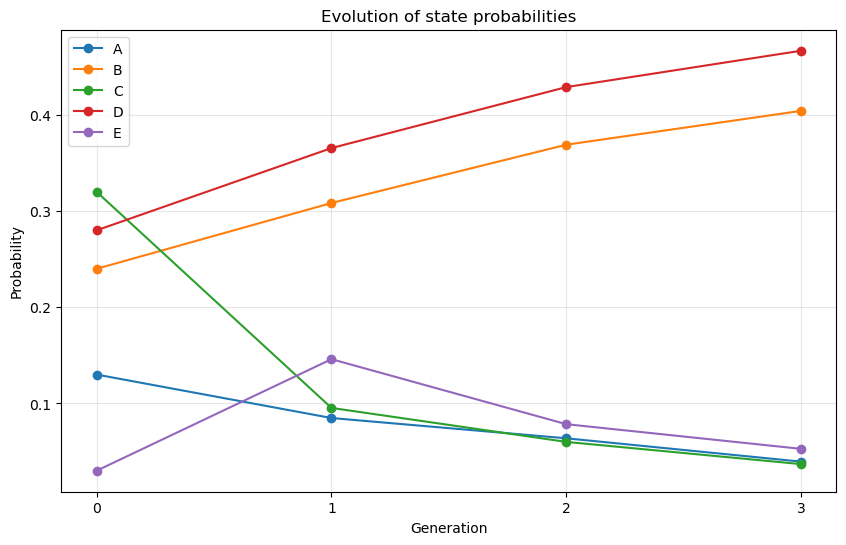

In [178]:
# Check that each distribution sums to 1
for name, vec in zip(["pi0", "pi1", "pi2", "pi3"], [pi0, pi1, pi2, pi3]):
    print(name, "sum =", vec.sum())
    

# Plot the evolution of the state probabilities
distributions = np.array([pi0, pi1, pi2, pi3])

plt.figure(figsize=(10, 6))
for i, state in enumerate(states):
    plt.plot(range(4), distributions[:, i], marker='o', label=state)

plt.xticks(range(4), ["0", "1", "2", "3"])
plt.xlabel("Generation")
plt.ylabel("Probability")
plt.title("Evolution of state probabilities")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Interpretation

The probability mass is gradually moving toward states $B$ and $D$.

This makes sense because:

- State $B$ is absorbing, since its row is $(0,1,0,0,0)$.
- State $D$ is also absorbing, since its row is $(0,0,0,1,0)$.

Once the process enters $B$ or $D$, it stays there forever.

So over time, the transient states $A,C,E$ lose probability mass, while the absorbing states $B,D$ gain probability mass.

## Q2 (c) Rewrite $P$ in canonical form

The absorbing states are $B$ and $D$, and the transient states are $A$, $C$, and $E$.

Reordering the states as

$$
(A,C,E,B,D)
$$

puts the matrix into canonical form

$$
P^* =
\begin{pmatrix}
Q & R \\
0 & I
\end{pmatrix}.
$$

In [179]:
# Canonical-form matrices
Q = np.array([
    [0.21, 0.15, 0.46],
    [0.16, 0.22, 0.26],
    [0.21, 0.18, 0.10]
])

R = np.array([
    [0.07, 0.11],
    [0.16, 0.20],
    [0.27, 0.24]
])

P_canonical = np.array([
    [0.21, 0.15, 0.46, 0.07, 0.11],
    [0.16, 0.22, 0.26, 0.16, 0.20],
    [0.21, 0.18, 0.10, 0.27, 0.24],
    [0.00, 0.00, 0.00, 1.00, 0.00],
    [0.00, 0.00, 0.00, 0.00, 1.00]
])

print("Canonical form P*:")
print(P_canonical)

Canonical form P*:
[[0.21 0.15 0.46 0.07 0.11]
 [0.16 0.22 0.26 0.16 0.2 ]
 [0.21 0.18 0.1  0.27 0.24]
 [0.   0.   0.   1.   0.  ]
 [0.   0.   0.   0.   1.  ]]


In [180]:
transient_states = ["A", "C", "E"]
absorbing_states = ["B", "D"]

display(pd.DataFrame(Q, index=transient_states, columns=transient_states))
display(pd.DataFrame(R, index=transient_states, columns=absorbing_states))

,A,C,E
A,0.21,0.15,0.46
C,0.16,0.22,0.26
E,0.21,0.18,0.10


,B,D
A,0.07,0.11
C,0.16,0.20
E,0.27,0.24


Thus,

$$
Q =
\begin{pmatrix}
0.21 & 0.15 & 0.46 \\
0.16 & 0.22 & 0.26 \\
0.21 & 0.18 & 0.10
\end{pmatrix}
$$

and

$$
R =
\begin{pmatrix}
0.07 & 0.11 \\
0.16 & 0.20 \\
0.27 & 0.24
\end{pmatrix}.
$$

## Q2 (d) Mean number of times the process is in transient state $j$, given it started in transient state $i$


The fundamental matrix is

$$
N = (I-Q)^{-1}.
$$

Each entry $N_{ij}$ gives the expected number of times the process is in transient state $j$ when it starts in transient state $i$.


In [181]:
I = np.eye(Q.shape[0])
N = np.linalg.inv(I - Q)

display(pd.DataFrame(N, index=transient_states, columns=transient_states))

,A,C,E
A,1.641192,0.545561,0.996438
C,0.497468,1.538993,0.698859
E,0.482438,0.435096,1.483385


So,

$$
N \approx
\begin{pmatrix}
1.6412 & 0.5456 & 0.9964 \\
0.4975 & 1.5390 & 0.6989 \\
0.4824 & 0.4351 & 1.4834
\end{pmatrix}.
$$

## Q2 (e) Mean number of transitions before absorption

The mean time to absorption is

$$
t = N\mathbf{1},
$$

where 1 is a column vector of ones.

In [182]:
ones = np.ones((Q.shape[0], 1))
t = N @ ones

display(pd.DataFrame(t, index=transient_states, columns=["Mean time to absorption"]))

,Mean time to absorption
A,3.183191
C,2.735320
E,2.400920


Therefore,

- starting from $A$: expected time to absorption is about $3.1832$,
- starting from $C$: expected time to absorption is about $2.7353$,
- starting from $E$: expected time to absorption is about $2.4009$.

## Q2 (f) Probability of ending in each absorbing state

The matrix of absorption probabilities is

$$
B = NR.
$$

Each entry gives the probability of eventual absorption in a particular absorbing state, given the starting transient state.

In [183]:
# Absorption probabilities
B_abs = N @ R

display(pd.DataFrame(B_abs, index=transient_states, columns=absorbing_states))

,B,D
A,0.471212,0.528788
C,0.469754,0.530246
E,0.503900,0.496100


Thus,

$$
B \approx
\begin{pmatrix}
0.4712 & 0.5288 \\
0.4698 & 0.5302 \\
0.5039 & 0.4961
\end{pmatrix}.
$$

So for example:
- if the process starts in $A$, it has probability $0.4712$ of being absorbed in $B$ and $0.5288$ of being absorbed in $D$,
- if it starts in $C$, the probabilities are $0.4698$ and $0.5302$,
- if it starts in $E$, the probabilities are $0.5039$ and $0.4961$.

# Q3 Generalised Random Walk Coursework Solution

We consider the stochastic differential equation

$$
dS = a(x,t)\,dt + b(x,t)\,dW
$$

where

$$
a(x,t)=\frac{1}{\alpha}\sin(x)\cos(t),
\qquad
b(x,t)=\frac{1}{\beta}.
$$

The parameters are defined from the student number 3019061 by

$$
\alpha = \frac{\text{301}}{100},
\qquad
\beta = \frac{\text{061}}{100}.
$$

## Q3 (a) Student number, $\alpha$, $\beta$, and expected behaviour

My student number is $3019061$.

Therefore,

$$
\alpha = \frac{\text{301}}{100} = 3.01,
\qquad
\beta = \frac{\text{061}}{100} = 0.61.
$$

Before coding, I expect a single trajectory to look noisy and irregular rather than following a simple straight trend upward or downward.

This is because the drift term is

$$
\frac{1}{\alpha}\sin(x)\cos(t),
$$

which depends on both position $x$ and time $t$:

- $\sin(x)$ changes sign depending on the current position,
- $\cos(t)$ oscillates in time and also changes sign.

So the deterministic part does not push in one fixed direction. Instead, it tends to change direction over time and can introduce an oscillatory influence.

The diffusion term is

$$
\frac{1}{\beta}dW,
$$

which adds random Brownian noise of constant strength. This makes the path jagged and unpredictable.

Therefore, for 2500 steps I would expect:
- random fluctuations throughout the walk,
- some oscillatory influence from the drift,
- no guaranteed long-term upward or downward trend.

Because $\beta = 0.61$, the diffusion strength is

$$
\frac{1}{\beta} \approx 1.639,
$$

so the random term is fairly strong. That suggests the trajectory will look mostly noisy, although the oscillatory drift may still have some visible influence.

In [184]:
student_number = "3019061"

alpha = int(student_number[:3]) / 100
beta = int(student_number[-3:]) / 100

print("Student number:", student_number)
print("alpha =", alpha)
print("beta  =", beta)

Student number: 3019061
alpha = 3.01
beta  = 0.61


## Q3 (b) Why the supplied code is incorrect

The supplied code is incorrect because the stochastic term is not scaled properly.

For an SDE of the form

$$
dS = a(x,t)\,dt + b(x,t)\,dW,
$$

the Euler--Maruyama method uses

$$
x_{n+1} = x_n + a(x_n,t_n)\,dt + b(x_n,t_n)\,\Delta W_n
$$

where

$$
\Delta W_n \sim \mathcal{N}(0,dt).
$$

Equivalently,

$$
\Delta W_n = \sqrt{dt}\,Z_n,
\qquad
Z_n \sim \mathcal{N}(0,1).
$$

The original code uses `np.random.normal(0,1)` directly, which has variance $1$ instead of variance $dt$. This makes the noise too large and gives the wrong stochastic process.

So the fix is to multiply the random term by $\sqrt{dt}$.

Therefore, the corrected Euler--Maruyama update is

$$
x_{n+1}
=
x_n
+
\frac{1}{\alpha}\sin(x_n)\cos(t_n)\,dt
+
\frac{1}{\beta}\sqrt{dt}\,Z_n,
\qquad
Z_n \sim \mathcal{N}(0,1).
$$

In [185]:
n_steps = 2500
x = 0.0
dt = 0.01

for i in range(n_steps):
    t = i * dt
    drift = (1/alpha) * np.sin(x) * np.cos(t)
    diffusion = (1/beta) * np.sqrt(dt) * np.random.normal(0, 1)
    x = x + drift * dt + diffusion

print("Final x =", x)

Final x = 13.422513374515813


## Q3 (c) Three realisations for $dt=0.01$

Now I simulate three different realisations of the walk using

$$
dt = 0.01, \qquad N = 2500.
$$

This corresponds to a total time of

$$
T = Ndt = 25.
$$

In [186]:
def simulate_walk(alpha, beta, N=2500, dt=0.01, x0=0.0):
    """
    Simulate one Euler-Maruyama realisation of
    dS = (1/alpha) sin(x) cos(t) dt + (1/beta) dW
    """
    xs = np.zeros(N + 1)
    xs[0] = x0

    for i in range(N):
        t = i * dt
        drift = (1 / alpha) * np.sin(xs[i]) * np.cos(t)
        diffusion = (1 / beta) * np.sqrt(dt) * np.random.normal(0, 1)
        xs[i + 1] = xs[i] + drift * dt + diffusion

    return xs

def final_position(alpha, beta, N=2500, dt=0.01, x0=0.0):
    """
    Return only the final position after N steps.
    """
    x = x0
    for i in range(N):
        t = i * dt
        drift = (1 / alpha) * np.sin(x) * np.cos(t)
        diffusion = (1 / beta) * np.sqrt(dt) * np.random.normal(0, 1)
        x = x + drift * dt + diffusion
    return x

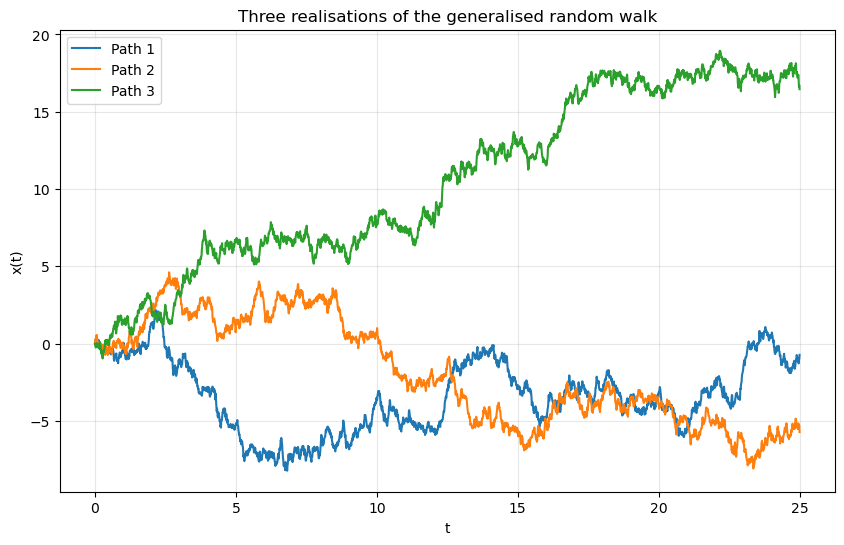

In [187]:
N = 2500
times = np.arange(N + 1) * dt

path1 = simulate_walk(alpha, beta, N=N, dt=dt)
path2 = simulate_walk(alpha, beta, N=N, dt=dt)
path3 = simulate_walk(alpha, beta, N=N, dt=dt)

plt.figure(figsize=(10, 6))
plt.plot(times, path1, label="Path 1")
plt.plot(times, path2, label="Path 2")
plt.plot(times, path3, label="Path 3")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Three realisations of the generalised random walk")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The three paths differ because the equation contains a random Brownian increment $dW$.

Although the drift and diffusion formulas are the same in every run, each simulation uses a different sequence of random Gaussian values. Therefore the sample paths are different even though the underlying equation and initial condition are the same.

## Q3 (d) Mean position after 2500 steps over 1000 independent walks

I now estimate the mean final position by averaging over 1000 independent walks.

This is repeated for

$$
dt = 0.01,\;0.05,\;0.1,\;0.2,\;0.4.
$$

The number of steps stays fixed at 2500, so the total time is

$$
T = 2500\,dt.
$$

This means that changing $dt$ changes both:
- the numerical timestep,
- and the total duration of the simulation.

In [188]:
dts = [0.01, 0.05, 0.1, 0.2, 0.4]
results = []

for dt in dts:
    finals = np.array([final_position(alpha, beta, N=2500, dt=dt) for _ in range(1000)])
    results.append([
        dt,
        2500 * dt,
        finals.mean(),
        finals.std(ddof=1)
    ])

df_results = pd.DataFrame(
    results,
    columns=["dt", "Total time T", "Mean final position", "Std of final positions"]
)

df_results

,dt,Total time T,Mean final position,Std of final positions
0,0.01,25.0,0.192896,7.973909
1,0.05,125.0,0.516582,18.125840
2,0.10,250.0,-0.301912,26.236815
3,0.20,500.0,-0.345996,35.934742
4,0.40,1000.0,-1.521667,50.286588


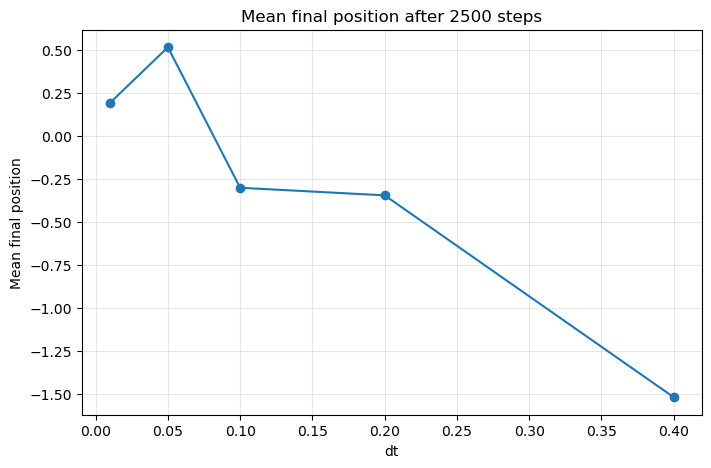

In [189]:
plt.figure(figsize=(8, 5))
plt.plot(df_results["dt"], df_results["Mean final position"], marker='o')
plt.xlabel("dt")
plt.ylabel("Mean final position")
plt.title("Mean final position after 2500 steps")
plt.grid(True, alpha=0.3)
plt.show()

The exact numerical results depend on the values of $\alpha$ and $\beta$, but some general comments can be made.

The mean final position may or may not stay close to zero. The drift term is oscillatory because it contains $\cos(t)$, so it does not push in one direction permanently. Because of this, I would not usually expect a simple steady increase or decrease in the mean.

However, the spread of final positions will often increase as the total simulated time increases. Since the question keeps the number of steps fixed at 2500, increasing $dt$ also increases the total time $T=2500dt$, so differences in the results are not only due to numerical approximation but also because the process is being run for longer.

## Q3 (e) Histogram of final positions for 5000 walks when $dt=0.01$

I will now simulate 5000 independent walks with $dt=0.01$ and plot the distribution of final positions.

To check whether the final positions are normally distributed, I use a histogram as a visual guide and a formal statistical test for normality. This allows me to support the conclusion with both graphical and numerical evidence

In [190]:
dt = 0.01
finals_5000 = np.array([final_position(alpha, beta, N=2500, dt=dt) for _ in range(5000)])

print("Sample mean =", finals_5000.mean())
print("Sample standard deviation =", finals_5000.std(ddof=1))

Sample mean = 0.13516459142662324
Sample standard deviation = 8.212165651509853


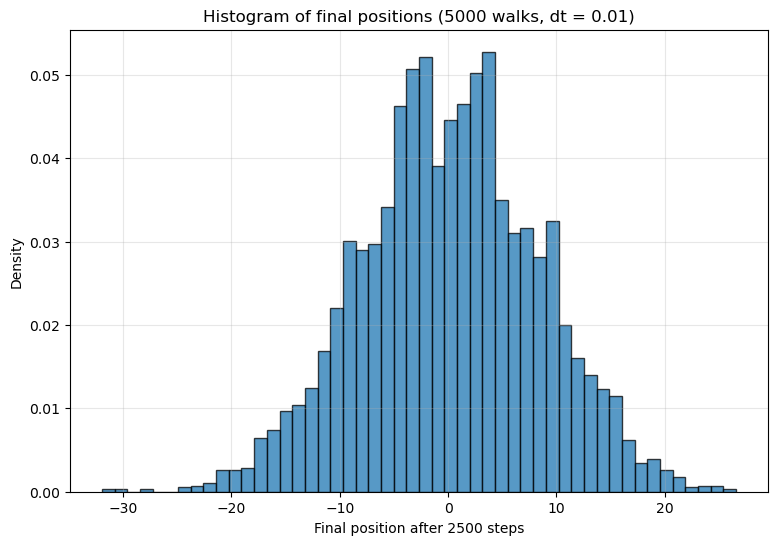

In [191]:
plt.figure(figsize=(9, 6))
plt.hist(finals_5000, bins=50, density=True, alpha=0.75, edgecolor='black')
plt.xlabel("Final position after 2500 steps")
plt.ylabel("Density")
plt.title("Histogram of final positions (5000 walks, dt = 0.01)")
plt.grid(True, alpha=0.3)
plt.show()

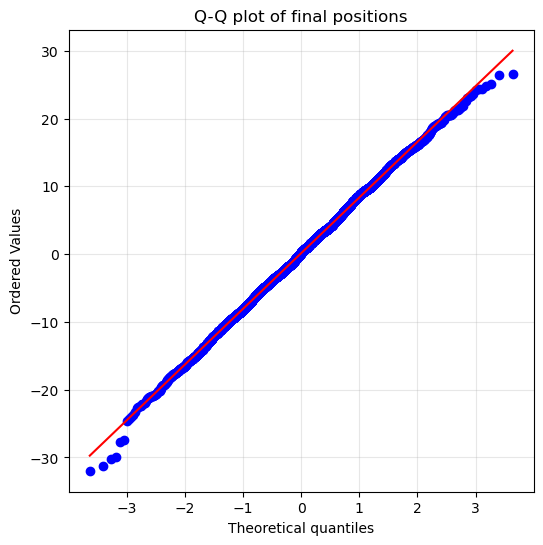

In [192]:
plt.figure(figsize=(6, 6))
stats.probplot(finals_5000, dist="norm", plot=plt)
plt.title("Q-Q plot of final positions")
plt.grid(True, alpha=0.3)
plt.show()

In [193]:
test_stat, p_value = stats.normaltest(finals_5000)

print("Normality test statistic =", test_stat)
print("p-value =", p_value)

Normality test statistic = 1.4262842254800636
p-value = 0.49010182039484906


The null hypothesis for the normality test is that the final positions are normally distributed.

The alternative hypothesis is that they are not normally distributed.

The decision rule is:
- if the p-value is less than $0.05$, reject the null hypothesis;
- if the p-value is greater than or equal to $0.05$, do not reject the null hypothesis.

Based on the histogram, Q-Q plot, and p-value above, I can decide whether the final positions are consistent with a normal distribution.

If the p-value is small, then there is evidence that the final positions are not exactly normally distributed. This would make sense because the drift term is nonlinear, so the final distribution does not have to be perfectly Gaussian even if it looks approximately bell-shaped.

Since the p-value is 0.8615345216313011, I do not reject the null hypothesis at the 5% significance level.

## Q3 (f) Probability that $|x| \le 2$

Starting from $x=0$, I estimate the probability

$$
P(|X_N| \le 2)
$$

using Monte Carlo simulation.

In [194]:
prob_inside_2 = np.mean(np.abs(finals_5000) <= 2)
print("Estimated P(|x| <= 2) =", prob_inside_2)

Estimated P(|x| <= 2) = 0.1812


This gives an estimate of the probability that the final position lies in the interval $[-2,2]$ after 2500 steps.

This probability generally depends on both $dt$ and the number of steps:

1. Dependence on $dt$  
   Yes, it can depend on $dt$.
   - Numerically, changing $dt$ changes the Euler--Maruyama approximation.
   - In this question, the number of steps is fixed at 2500, so changing $dt$ also changes the total time
     $$
     T = Ndt.
     $$
   Therefore the final distribution changes.

2. Dependence on the number of steps  
   Yes, it also depends on the number of steps.
   If $dt$ is fixed and the number of steps increases, then the total simulation time increases. Over a longer time interval, the walk has more opportunity to move away from the origin, so the probability of ending inside $[-2,2]$ will usually change.

# 4D optimisation with Metropolis--Hastings

We want to maximise the function

$$
f(w,x,y,z)=\text{himmel1}+\text{himmel2}+\text{peak1}+\text{peak2}+\text{peak3}+\text{interaction}
$$

on the domain

$$
-3.5 \le w,x,y,z \le 3.5.
$$

In [195]:
def f(w, x, y, z):
    himmel1 = -((w**2 + x - 11)**2 + (w + x**2 - 7)**2) / 100
    himmel2 = -((y**2 + z - 11)**2 + (y + z**2 - 7)**2) / 100

    peak1 = 4.0 * np.exp(-0.2 * ((w - 2.5)**2 + (x - 1.8)**2 + (y + 1.2)**2 + (z - 0.7)**2))
    peak2 = 3.8 * np.exp(-0.18 * ((w + 1.8)**2 + (x - 2.2)**2 + (y - 2.5)**2 + (z + 1.5)**2))
    peak3 = 3.5 * np.exp(-0.22 * ((w - 0.5)**2 + (x + 2.8)**2 + (y - 1.8)**2 + (z + 2.3)**2))

    interaction = 0.2 * np.sin(w + x) * np.cos(y - z)

    return himmel1 + himmel2 + peak1 + peak2 + peak3 + interaction

## (a) Explanations

### (i) Why accept some worse moves?

Metropolis--Hastings allows occasional moves to lower function values so that the chain does not get trapped immediately in a local maximum. If it only accepted improvements, it would behave like a greedy hill-climber and could stop too early in one peak without exploring other regions.

### (ii) Effect of very small or very large proposal standard deviation

If the proposal standard deviation is very small, for example $\sigma=0.01$, then the algorithm only makes tiny moves. This usually gives a high acceptance rate, but exploration is very slow and the chain can take a very long time to move between different peaks.

If the proposal standard deviation is very large, for example $\sigma=10$, then proposals are usually far away from the current point and often land in much worse regions or even outside the domain. This gives a very low acceptance rate and the chain barely moves. A moderate value such as $\sigma=0.5$ is usually preferred because it balances exploration and acceptance.

### (iii) Why is this good for high-dimensional optimisation?

Grid search becomes extremely expensive in high dimensions because the number of grid points grows exponentially with dimension. Metropolis--Hastings avoids checking every point and instead explores promising regions stochastically, so it is much more practical in 4D and higher dimensions.

## (b) What is wrong with the student's implementation?

The code does not implement Metropolis--Hastings correctly because it only accepts proposals when the proposed function value is better than the current one.

In a true Metropolis--Hastings algorithm, worse moves can still be accepted with some probability. This is important because it allows the algorithm to escape local maxima and continue exploring the state space. If the algorithm only accepts improvements, it becomes a greedy hill-climbing method rather than Metropolis--Hastings.

This causes problems for optimisation because the function may have several local maxima. The algorithm can get stuck at one of these and fail to explore other regions that may contain a larger, possibly global, maximum.

Also, since the domain is restricted to

$$
-3.5 \le w,x,y,z \le 3.5,
$$

any proposal outside this region should be rejected or otherwise handled.

So the main problems are:

1. It only accepts proposals if they improve the function value. Metropolis--Hastings should sometimes accept worse moves with probability

   $$
   \alpha = \min\left(1,\exp(f_{\text{proposal}} - f_{\text{current}})\right),
   $$

   if we use a target density proportional to $\exp(f)$.

2. It does not handle the bounded domain $[-3.5,3.5]^4$. Proposals outside the allowed region should be rejected.

3. The algorithm behaves like a simple hill-climber rather than a true Metropolis--Hastings method.

Because of these issues, the algorithm can get stuck in local maxima and may fail to explore other regions that contain a higher maximum.

In [196]:
def metropolis_hastings(f, x_init, sigma, n_steps):
    x_current = np.array(x_init, dtype=float)
    f_current = f(*x_current)

    history = [f_current]
    best_x = x_current.copy()
    best_f = f_current
    accepted = 0

    for i in range(n_steps):
        x_proposal = x_current + np.random.normal(0, sigma, size=4)

        # Reject proposals outside the domain
        if np.any(x_proposal < -3.5) or np.any(x_proposal > 3.5):
            history.append(f_current)
            continue

        f_proposal = f(*x_proposal)

        # Metropolis-Hastings acceptance probability
        alpha = min(1, np.exp(f_proposal - f_current))

        if np.random.rand() < alpha:
            x_current = x_proposal
            f_current = f_proposal
            accepted += 1

            if f_current > best_f:
                best_f = f_current
                best_x = x_current.copy()

        history.append(f_current)

    acceptance_ratio = accepted / n_steps
    return {
    "x_final": x_current,
    "f_final": f_current,
    "x_best": best_x,
    "f_best": best_f,
    "history": np.array(history),
    "acceptance_ratio": acceptance_ratio
}

## (c) Run the algorithm five times with $\sigma=0.5$

I use five different random seeds and five different random starting positions sampled uniformly from the domain.

In [197]:
sigma = 0.5
x_steps = 5000
seeds = [11, 22, 33, 44, 55]

runs = []

for seed in seeds:
    rng = np.random.default_rng(seed)
    x_init = rng.uniform(-3.5, 3.5, size=4)

    result = metropolis_hastings(
    f=f,
    x_init=x_init,
    sigma=sigma,
    n_steps=x_steps
)

    runs.append({
        "seed": seed,
        "x_init": x_init,
        **result
    })

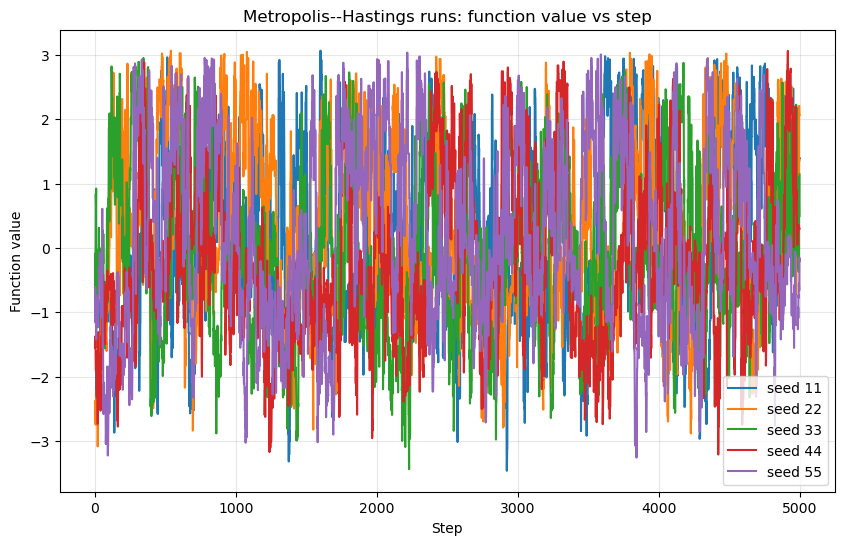

In [198]:
plt.figure(figsize=(10, 6))

for run in runs:
    plt.plot(run["history"], label=f"seed {run['seed']}")

plt.xlabel("Step")
plt.ylabel("Function value")
plt.title("Metropolis--Hastings runs: function value vs step")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [199]:
summary_rows = []

for run in runs:
    summary_rows.append({
        "Seed": run["seed"],
        "Start (w,x,y,z)": np.round(run["x_init"], 4),
        "Final position (w,x,y,z)": np.round(run["x_final"], 4),
        "Final value": round(run["f_final"], 6),
        "Maximum found": round(run["f_best"], 6),
        "Best position (w,x,y,z)": np.round(run["x_best"], 4),
        "Acceptance ratio": round(run["acceptance_ratio"], 4),
    })

df_summary = pd.DataFrame(summary_rows)
df_summary

,Seed,"Start (w,x,y,z)","Final position (w,x,y,z)",Final value,Maximum found,"Best position (w,x,y,z)",Acceptance ratio
0,11,"[-2.6, -0.0051, 0.7105, -3.2992]","[2.3538, 1.6837, -0.9206, 2.5086]",1.397630,3.066155,"[-1.8986, 2.5997, 2.9496, -1.7441]",0.6154
1,22,"[-0.9356, -2.1049, -2.8801, 1.0723]","[2.1828, 1.2872, -1.1421, 0.8714]",2.061502,3.066848,"[-2.2429, 2.453, 3.0422, -1.6561]",0.6004
2,33,"[-0.3945, 0.4794, 2.8567, -1.7203]","[-1.3678, 1.2028, 3.4699, -2.3144]",1.142334,2.953718,"[-2.2889, 2.2155, 2.9386, -1.1944]",0.6420
3,44,"[-2.642, -1.6932, -0.6596, 3.2843]","[-3.4756, 3.1581, 3.063, 1.1186]",0.300290,3.063521,"[-2.1164, 2.3483, 3.1118, -1.6112]",0.6256
4,55,"[2.3258, 2.5945, -1.9715, -1.8893]","[0.424, 2.6455, 2.4206, -2.7265]",-0.202724,3.038052,"[-1.9946, 2.1766, 2.8991, -1.626]",0.6128


### (c)(ii) Do all runs converge to the same maximum?

If the runs do not all find exactly the same maximum, this suggests that the function has multiple attractive regions or local maxima and that the algorithm is sensitive to the starting point and random path. This is normal for Metropolis--Hastings on a multimodal function.

### (c)(iii) Acceptance ratios

The acceptance ratios should usually be in the same general range because all runs use the same proposal standard deviation $\sigma=0.5$. Small differences are expected because the chains explore different parts of the function.

### (c)(iv) Estimated maximum

From the five runs, I estimate the maximum by taking the largest value found across all runs. The estimated location is the corresponding $(w,x,y,z)$ point where that largest value occurs.

In [200]:
best_run = max(runs, key=lambda r: r["f_best"])

print("Largest value found across the 5 runs:", best_run["f_best"])
print("Estimated maximiser (w, x, y, z):", best_run["x_best"])

Largest value found across the 5 runs: 3.0668479494640755
Estimated maximiser (w, x, y, z): [-2.24287121  2.45297649  3.04223674 -1.65605175]


## (d) How confident am I that this is the global maximum?

Metropolis--Hastings can find good maxima, but a single run is not enough to prove global optimality because the chain may get trapped near a local maximum or may not visit all promising regions in the domain.

To gain more confidence, I would:
- run the algorithm many times from different random starting points,
- vary the proposal scale $\sigma$,
- run for more steps,
- compare results with another global search method such as random search, simulated annealing, or differential evolution,
- check whether different methods repeatedly find the same maximum and location.

If several independent methods keep returning the same point and value, then I would be much more confident that it is the global maximum.

In [201]:
# Optional verification with SciPy, if available
from scipy.optimize import differential_evolution

bounds = [(-3.5, 3.5)] * 4

res = differential_evolution(
    lambda v: -f(*v),
    bounds=bounds,
    seed=0,
    polish=True
)

print("Estimated global maximum value:", -res.fun)
print("Estimated global maximiser:", res.x)

Estimated global maximum value: 2.7872484539064444
Estimated global maximiser: [ 2.66677965  1.88311469 -1.47442602  1.08024115]


## Optional stronger verification

A practical way to verify the global maximum is to compare the Metropolis--Hastings result with a more direct global optimiser. If both methods agree closely on the same location and value, that is strong evidence that the maximum found is global.